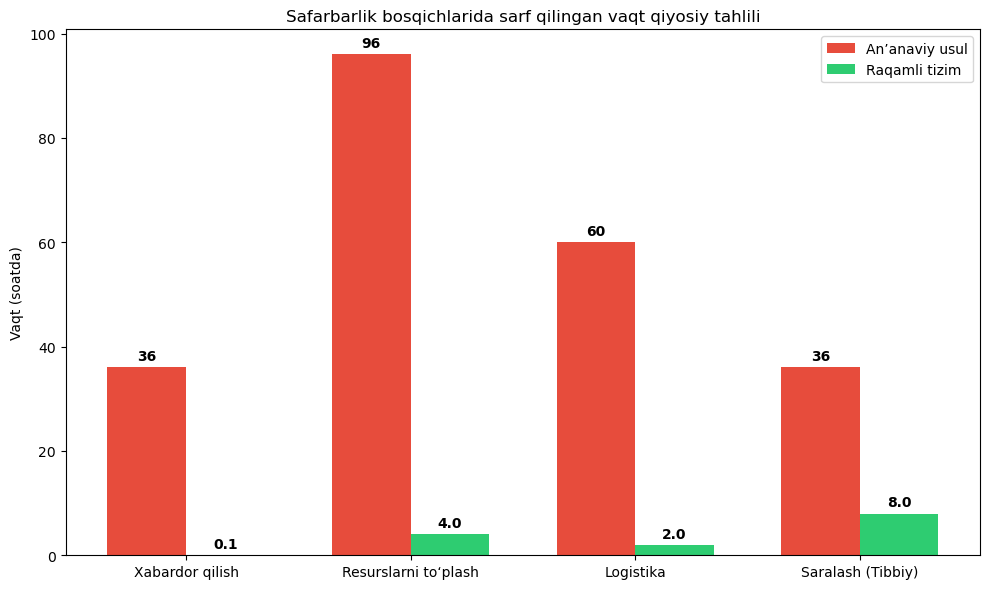

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Ma'lumotlar (Sarf qilingan vaqt - soatlarda)
stages = [
    'Xabardor qilish', 
    'Resurslarni to‘plash', 
    'Logistika', 
    'Saralash (Tibbiy)'
]
traditional_time = [36, 96, 60, 36]  # An'anaviy usul
digital_time = [0.1, 4, 2, 8]        # Raqamli tizim

x = np.arange(len(stages))  # Bosqichlar o'rni
width = 0.35                # Ustunlar kengligi

fig, ax = plt.subplots(figsize=(10, 6))

# Ustunlarni chizish
rects1 = ax.bar(x - width/2, traditional_time, width, label='An’anaviy usul', color='#e74c3c')
rects2 = ax.bar(x + width/2, digital_time, width, label='Raqamli tizim', color='#2ecc71')

# Grafikni bezash
ax.set_ylabel('Vaqt (soatda)')
ax.set_title('Safarbarlik bosqichlarida sarf qilingan vaqt qiyosiy tahlili')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()

# Ustunlar ustiga qiymatlarni yozib chiqish funksiyasi
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# Grafikni saqlash yoki ko'rsatish
plt.show()

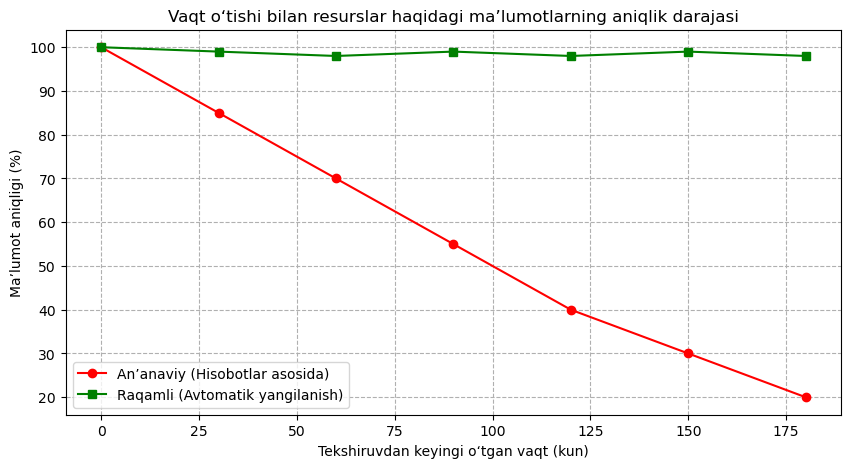

In [2]:
import matplotlib.pyplot as plt

# Ma'lumotning aniqlik darajasi (vaqt o'tishi bilan)
days = [0, 30, 60, 90, 120, 150, 180] # Kunlar
accuracy_manual = [100, 85, 70, 55, 40, 30, 20] # An'anaviy tizimda
accuracy_digital = [100, 99, 98, 99, 98, 99, 98] # Raqamli (real-time) tizimda

plt.figure(figsize=(10, 5))
plt.plot(days, accuracy_manual, 'r-o', label='An’anaviy (Hisobotlar asosida)')
plt.plot(days, accuracy_digital, 'g-s', label='Raqamli (Avtomatik yangilanish)')

plt.title('Vaqt o‘tishi bilan resurslar haqidagi ma’lumotlarning aniqlik darajasi')
plt.xlabel('Tekshiruvdan keyingi o‘tgan vaqt (kun)')
plt.ylabel('Ma’lumot aniqligi (%)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


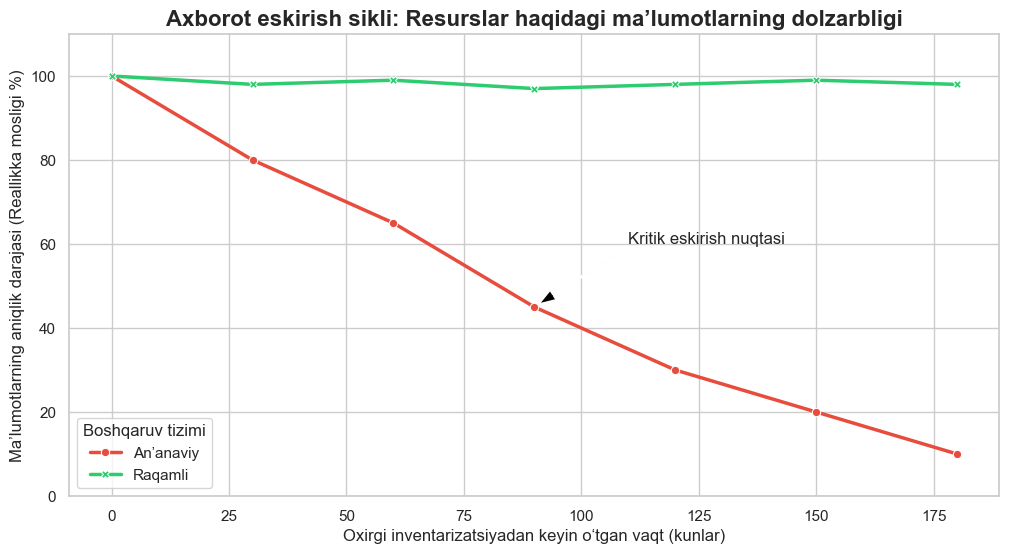

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ma'lumotlarni tayyorlash
data = {
    'Vaqt (Kunlar)': [0, 30, 60, 90, 120, 150, 180, 0, 30, 60, 90, 120, 150, 180],
    'Aniqlik darajasi (%)': [100, 80, 65, 45, 30, 20, 10, 100, 98, 99, 97, 98, 99, 98],
    'Tizim turi': ['An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 'An’anaviy', 
                   'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli', 'Raqamli']
}

df = pd.DataFrame(data)

# Seaborn stilini sozlash
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Grafikni chizish
line_plot = sns.lineplot(data=df, x='Vaqt (Kunlar)', y='Aniqlik darajasi (%)', 
                         hue='Tizim turi', style='Tizim turi', 
                         markers=True, dashes=False, palette=['#e74c3c', '#2ecc71'], linewidth=2.5)

# Grafik bezaklari
plt.title('Axborot eskirish sikli: Resurslar haqidagi ma’lumotlarning dolzarbligi', fontsize=16, fontweight='bold')
plt.xlabel('Oxirgi inventarizatsiyadan keyin o‘tgan vaqt (kunlar)', fontsize=12)
plt.ylabel('Ma’lumotlarning aniqlik darajasi (Reallikka mosligi %)', fontsize=12)
plt.ylim(0, 110)

# Muhim nuqtaga izoh qo'shish (An'anaviy tizim inqirozi)
plt.annotate('Kritik eskirish nuqtasi', xy=(90, 45), xytext=(110, 60),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.legend(title='Boshqaruv tizimi')
plt.show()

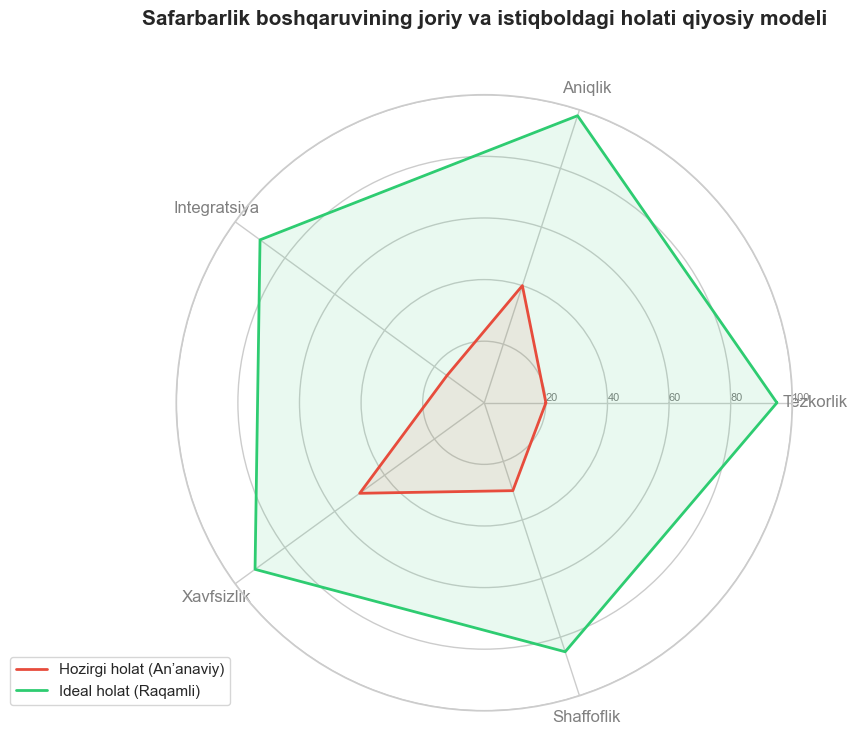

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# 1. Ma'lumotlarni shakllantirish
# Mezonlar: Tezkorlik, Aniqlik, Integratsiya, Xavfsizlik, Shaffoflik
df = pd.DataFrame({
    'group': ['Hozirgi holat (An’anaviy)', 'Ideal holat (Raqamli)'],
    'Tezkorlik': [20, 95],
    'Aniqlik': [40, 98],
    'Integratsiya': [15, 90],
    'Xavfsizlik': [50, 92],
    'Shaffoflik': [30, 85]
})

# 2. Radar chart uchun koordinatalarni tayyorlash
categories = list(df)[1:]
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# Birinchi chiziqni chizish (Hozirgi holat)
values = df.loc[0].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Hozirgi holat (An’anaviy)", color='#e74c3c')
ax.fill(angles, values, '#e74c3c', alpha=0.1)

# Ikkinchi chiziqni chizish (Ideal holat)
values = df.loc[1].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Ideal holat (Raqamli)", color='#2ecc71')
ax.fill(angles, values, '#2ecc71', alpha=0.1)

# Bezaklar
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="grey", size=8)
plt.ylim(0, 100)

plt.title('Safarbarlik boshqaruvining joriy va istiqboldagi holati qiyosiy modeli', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.show()